We will use the jupyter notebook tutorial 'HST_astroquery_science_case_white_dwarfs' along with the website: https://mast.stsci.edu/vo-tap/api/v0.1/hsc/examples

The ESA HST archive will be used: https://astroquery.readthedocs.io/en/latest/esa/hubble/hubble.html. As they point out, all data is identical, and retrieval will be much easier. 

# Cone Search of Observations

We begin by importing ESAHubble into our code

In [4]:
# Import ESAHubble from astroquery.esa.hubble

from astroquery.esa.hubble import ESAHubble
esahubble = ESAHubble()
esahubble.get_status_messages()

Retrieve the desired target. Since we're interested initially in 3C273, we go to Courvoisier’s review chapter on 3C 273: https://ned.ipac.caltech.edu/level5/March02/Courvoisier/Cour6.html. We double check this information with 

From Figure 10, we find the RA's and DEC's of the traversing jet. We focus on the **knot C** located at: 
- DEC = 02 19 30
- RA = 12 15 32.5

The plus-minus cone to search for is not quite clear, but we can take $\pm 1$ arcsec for now. 

However, we notice ESA (https://esahubble.org/images/opo0303c/) takes the coordinates of 3C 273 to be: 
- Position (RA):	12 29 6.80
- Position (Dec):	2° 3' 7.64"
- Field of view:	0.79 x 0.95 arcminutes

Let's start by using ESA's approach, and then focusing on distinct parts. This will be useful because we start in a borader file and then filter our way through (as I'm more used to doing). 

In [5]:
from astropy import coordinates
from astroquery.esa.hubble import ESAHubble
import astropy.units as u
# Target coordinates
c = coordinates.SkyCoord(
    "12h29m06.80s +02d03m07.64s",
    frame='icrs'
)

'''Don't do cone-search yet, since we're first interested in a search of observations
# Cone search with radius in arcminutes
table = esahubble.cone_search(
    coordinates=c,
    radius=0.6 * u.arcmin, # since 0.95/2≈0.475 arcmin (radius to use), but we enlarge it for some more coverage
    filename="cone_search_3C273.vot.gz"
)
'''

'Don\'t do cone-search yet, since we\'re first interested in a search of observations\n# Cone search with radius in arcminutes\ntable = esahubble.cone_search(\n    coordinates=c,\n    radius=0.6 * u.arcmin, # since 0.95/2≈0.475 arcmin (radius to use), but we enlarge it for some more coverage\n    filename="cone_search_3C273.vot.gz"\n)\n'

We want to filter by: 
- Telescope = Hubble ---> I'm doing HST now, which is raw data, but I should consider taking HLA which is processed data
- Data-type = image / spectrum (if one exists)
- Intent = Science (NOT interested in calibration)
- Calibration level != raw

For the callibration leve, the line:                                         
- calibration_level = 2, # RAW = 1, and others are CALIBRATED and PRODUCT (both work)                                        

is giving significant errors

---

Optional Parameters for later on: 
- exposure_duration
- wave_bandwidth (changes the precision of observation)

In [7]:
result = esahubble.cone_search_criteria(coordinates=c,
                                        radius=0.475*u.arcmin,
                                        obs_collection=['HST'],
                                        #data_product_type = 'image',
                                        instrument_name = ['ACS/WFC'], # or 'WFPC2', etc. 
                                        filters = ['F435W'], # or 'F606W', etc. 
                                        async_job = True,
                                        filename = 'cone_search_3C273.vot.vot.gz',
                                        output_format="votable")

print(f'Retrieved {len(result)} results')

Retrieved 12 results


In [8]:
result

band_name,calibration_level,collection,data_product_type,dec,doi,end_time,end_time_mjd,exposure_duration,filter,fov_size,instrument_configuration,instrument_name,intent,last_modified,main_science_plane,members,members_number,observation_id,obs_type,pi_name,proposal_id,provenance_reference,ra,release_date,start_time,start_time_mjd,stc_s,target_description,target_moving,target_name,title,vis_image,vis_spectra,wave_bandwidth,wave_central,wave_max,wave_min
,,,,deg,,,d,s,,,,,,,,,,,,,,,deg,,,d,,,,,,,,nm,nm,nm,nm
object,int32,str64,str64,float64,str1024,object,float64,float64,object,float64,object,str64,str32,object,bool,object,int32,str256,object,str64,str256,object,float64,object,object,float64,object,object,bool,object,object,bool,bool,float64,float64,float64,float64
Optical,3,HST,image,2.0458666025956376,10.5270/esa-m2xsuix,2004-04-19 21:03:45.774431+00,53114.87761313,1821.0,F435W,0.042063774761542855,APERTURE=WFC2-ORAMP|DETECTOR=WFC|EXPEND=53114.87761313|EXPSTART=53114.802381|EXPTIME=1821.0|FILTER=F435W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,ACS/WFC,science,2025-08-28T02:19:20.602,True,caom:HST/hst_9294_03_acs_wfc_f435w_j8ea03fg caom:HST/hst_9294_03_acs_wfc_f435w_j8ea03fh caom:HST/hst_9294_03_acs_wfc_f435w_j8ea03fi caom:HST/hst_9294_03_acs_wfc_f435w_j8ea03fn caom:HST/hst_9294_03_acs_wfc_f435w_j8ea03fw,5,hst_9294_03_acs_wfc_f435w_j8ea03,HAP,"Ford, Holland",9294,http://www.stsci.edu/hst/acs/,187.27552773015861,2005-04-19T19:15:26.0,2004-04-19 19:15:25.7184+00,53114.802381,Polygon 187.29624303065174 2.042167304076197 187.27250576205927 2.0266396580798673 187.27206103967154 2.026542434988624 187.25475825920023 2.0492784149495824 187.2787597524431 2.06534798933241 187.27902381282584 2.0653340998807677,TARGET_DESCRIP=GALAXY;QUASAR,False,3C273,Observations of the Host Galaxy of 3C 273,True,False,109.99999999999996,424.99999999999994,479.99999999999994,370.0
Optical,2,HST,image,2.045854858271227,10.5270/esa-m2xsuix,2004-04-19 19:15:27.758305+00,53114.80240461,1.0,F435W,0.04182872236703157,APERTURE=WFC2-ORAMP|DETECTOR=WFC|EXPEND=53114.80240461|EXPSTART=53114.802381|EXPTIME=1.0|FILTER=F435W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,ACS/WFC,science,2025-08-28T02:19:07.607,True,caom:HST/j8ea03fgq,1,hst_9294_03_acs_wfc_f435w_j8ea03fg,HAP,"Ford, Holland",9294,http://www.stsci.edu/hst/acs/,187.27564244737314,2005-04-19T19:15:26.0,2004-04-19 19:15:25.7184+00,53114.802381,Polygon 187.29624303065174 2.042167304076197 187.27228340101138 2.026514657669272 187.25499452156131 2.049264529099477 187.27902381282584 2.0653340998807677,TARGET_DESCRIP=GALAXY;QUASAR,False,3C273,Observations of the Host Galaxy of 3C 273,True,False,109.99999999999996,424.99999999999994,479.99999999999994,370.0
Optical,2,HST,image,2.045854858271227,10.5270/esa-m2xsuix,2004-04-19 19:18:42.734592+00,53114.80466128,5.0,F435W,0.04182872236703157,APERTURE=WFC2-ORAMP|DETECTOR=WFC|EXPEND=53114.80466128|EXPSTART=53114.80459174|EXPTIME=5.0|FILTER=F435W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,ACS/WFC,science,2025-08-28T02:19:19.558,True,caom:HST/j8ea03fhq,1,hst_9294_03_acs_wfc_f435w_j8ea03fh,HAP,"Ford, Holland",9294,http://www.stsci.edu/hst/acs/,187.27564244737314,2005-04-19T19:15:26.0,2004-04-19 19:18:36.726336+00,53114.80459174,Polygon 187.29624303065174 2.042167304076197 187.27228340101138 2.026514657669272 187.25499452156131 2.049264529099477 187.27902381282584 2.0653340998807677,TARGET_DESCRIP=GALAXY;QUASAR,False,3C273,Observations of the Host Galaxy of 3C 273,True,False,109.99999999999996,424.99999999999994,479.99999999999994,370.0
Optical,2,HST,image,2.045854858271227,10.5270/esa-m2xsuix,2004-04-19 19:31:55.75872+00,53114.8138398,605.0,F435W,0.04182872236703157,APERTURE=WFC2-ORAMP|DETECTOR=WFC|EXPEND=53114.8138398|EXPSTART=53114.80682545|EXPTIME=605.0|FILTER=F435W|IMAGETYP=EXT|OBSMODE=ACCUM|OBSTYPE=IMAGING,ACS/WFC,science,2025-08-28T02:19:15.671,True,caom:HST/j8ea03fiq,1,hst_9294_03_acs_wfc_f435w_j8ea03fi,HAP,"Ford, Holland",9294,http://www.stsci.edu/hst/acs/,187.27564244

We notice that the observation_id = hst_9294_03_acs_wfc_f435w_j8ea03 has a duration of exposure = 1821 s. Below, we retrieve this data in a fits file: 

In [11]:
esahubble.download_fits_files(observation_id="hst_9294_03_acs_wfc_f435w_j8ea03")

# Analyzing 1 fits file: 

## Metadata Header [0] information

In [13]:
from astropy.io import fits
hdul = fits.open('hst_9294_03_acs_wfc_f435w_j8ea03_drz.fits')
hdul.info()

Filename: hst_9294_03_acs_wfc_f435w_j8ea03_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     830   ()      
  1  SCI           1 ImageHDU        79   (2986, 2981)   float32   
  2  WHT           1 ImageHDU        45   (2986, 2981)   float32   
  3  CTX           1 ImageHDU        38   (2986, 2981)   int32   
  4  HDRTAB        1 BinTableHDU    638   5R x 314C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 10A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 1A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, D, D, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 3A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 43A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A, D, 

In [14]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2025-08-27'         / date this file was written (yyyy-mm-dd)        
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
                                                                                
TELESCOP= 'HST'                / telescope used to acquire data                 
BSIDEOPS= 'FALSE'              / Post-2021-07-15 B-Side Operations Indicator    
INSTRUME= 'ACS   '             / identifier for instrument used to acquire data 
EQUINOX =               2000.0 / equinox of celestial coord. system             
                            

From above, we observe: 
- FILTER1 = 'CLEAR1L           ' / element selected from filter wheel 1           
- FILTER2 = 'F435W             ' / element selected from filter wheel 2

If we go to https://svo2.cab.inta-csic.es/svo/theory/fps/ to check out the filter curves, we see it is not even listed as a filter. This should not be surprising, since in our querying we only included the 'F435W' filter. 

Indeed, the clear filter *provides a higher signal-to-noise ratio for faint targets, but at the cost of poorer resolution*. Yet, it is safe to assume it doesn't unevenly filter electrons as is the case for other HST filters. CHATGPT EXPLANATION: *“The CLEAR1L element is effectively a transparent optical element used in conjunction with F435W. The spectral selection is therefore dominated by the F435W filter itself. While broader passbands can increase photon throughput and improve signal-to-noise ratios for faint sources, they do not directly degrade the intrinsic angular resolution of the telescope.”*

In addition, we download the 'F435W' filter curve (https://svo2.cab.inta-csic.es/svo/theory/fps/index.php?id=HST/ACS_WFC.F435W&&mode=browse&gname=HST&gname2=ACS_WFC#filter) to complete the analysis developed in notebooks 2.1, 2.2. 

# SCI Header Info

## Overview

In [15]:
hdul[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2986                                                  
NAXIS2  =                 2981                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
INHERIT =                    T / inherit the primary header                     
EXTNAME = 'SCI     '           / extension name                                 
EXTVER  =                    1                                                  
EXPNAME = 'j8ea03fgq                ' / exposure identifier                     
BUNIT   = 'ELECTRONS/S'        / Units of science product                       
                            

We are especially interested in: 
- BUNIT   = 'ELECTRONS/S'        / Units of science product 
- PHOTFLAM=        3.1081179E-19 / inverse sensitivity, ergs/cm2/Ang/electron
- PHOTPLAM=        4.3291694E+03 / Pivot wavelength (Angstroms)
- PHOTBW  =        2.9898074E+02 / RMS bandwidth of filter plus detector

PHOTBW & PHOT PLAM indicate the pivot wavelength and bandwidth of our detector. 

Below we examine the relationship b/t BUNIT and PHOTFLAM to recover Flux. 

## Converting BUNIT to Flux:

From https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://hst-docs.stsci.edu/acsdhb/chapter-5-acs-data-analysis/5-1-photometry&ved=2ahUKEwiw7cWG3beUAxXZHUQIHbLrLIsQFnoECBgQAQ&usg=AOvVaw2lb_h7OWFvZKBkYQJcypDL, they define *PHOTFLAM is the mean flux density (in erg cm–2 sec–1 Å–1) that produces 1 count per second in the HST observing mode ( PHOTMODE ) used for the observation.*

In other words, PHOTFLAM is a calibration constant that converts your image units into physical flux density. We know $PHOTFLAM=\frac{F_{\lambda}}{count_{rate}}$, where 'count rate = 1 $e⁻ s⁻¹$ ', or equivalently: $$F_λ=(e^− * s^{−1})×PHOTFLAM$$, where $F_λ$ is energy flux per wavelength. We have seen, then, how PHOTFLAM already encodes:
- telescope mirror efficiency
- filter transmission (F435W here)
- CCD quantum efficiency
full system throughput

In [16]:
data = hdul[1].data
photflam = hdul[1].header["PHOTFLAM"]

flux_lambda = data * photflam

In [17]:
print(flux_lambda)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


Important note: We are able to use the simple $F_λ=(e^− * s^{−1})×PHOTFLAM$ correlation because the following conditions are met: 
- BUNIT = ELECTRONS/S
- image is DRZ / DRC / drizzled product
- ACS/WFC calibrated pipeline product
- no need for pixel-area correction

Otherwise, we would need to correctly calibrate everything. Yet, from header, we see this work has already been done for us (fortunately!).

## SED Wavelength

We know PHOTPLAM = pivot wavelength of the filter (4329 A˚ for our particular case). Pivot wavelength is espcially convenient because it is NOT source-dependent, but rather it depends only on the filter curve which remains unchanged.

Yet, for non-flat spectra, we can have some steep source such that $F \propto ν^{\alpha}$, such that the “average flux density” inferred using PHOTFLAM no longer corresponds exactly to the true spectrum evaluated at $λ_{pivot}$. That is, there is more flux to either side of PIVOT, and so our pivot wavelength is no longer exactly representative of our flux. 

Hence, we now have two options: 
1. Use Pivot Wavelength
2. Use a flux-weighted center of observation (model dependent)

We shall begin using the Pivot Wavelength, both for simplicity and to avoid inducing a new source of bias. Later in our analysis, we can consider creating a model of our spectral index, and iterate to find the best fit and better infer properties of the electron population. 


Below we also include the filter file just for reference. No work should be done for now, since we know we can rely initially on PHOTPLAM. Flux density per pixel:

In [18]:
import numpy as np
F435W_filter_curve = np.loadtxt("HST_ACS_WFC.F435W.dat", delimiter = " ")

In [19]:
print(F435W_filter_curve[:, 1])

[7.59730e-05 8.65020e-05 9.70997e-05 ... 9.34836e-05 8.54017e-05
 7.73180e-05]


# Analyzing the Region for SED

## WCS Inspection

### Header Analysis

We have the data in the hdul[1].data, which is an array of arrays. In essence, each index in row and column corresponds to a pixel in the sky, and the value of that cell is the counts (in e- / s). This is better understood as counts = data[y,x], where (x,y) corresponds to a sky pixel. 

To recover positions in the sky, we must use WCS

In [20]:
hdul[2].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2986                                                  
NAXIS2  =                 2981                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
INHERIT =                    T / inherit the primary header                     
EXTNAME = 'WHT     '           / extension name                                 
EXTVER  =                    1                                                  
EXPNAME = 'j8ea03fgq                ' / exposure identifier                     
                                                                                
CD1_1   = -1.3888888888888E-

- the pixel CRPIX1 & CRPIX2 correspond to the sky coordinates CRVAL
- CRVAL is the reference sky coordinate defined by (RA,Dec)=(CRVAL1, CRVAL2) in degrees.
- the CD values comprise a matrix that converts pixel offsets ---> angular offsets. 

In [21]:
# CONVERTING PIXELS TO SKY COORDS: 
from astropy.wcs import WCS

wcs = WCS(hdul[1].header)
ra, dec = wcs.pixel_to_world_values(x, y)

NameError: name 'x' is not defined

### Plotting Fluxes (RA-DEC): 

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.visualization import PercentileInterval

# -----------------------------
# LOAD DATA
# -----------------------------

data = hdul[1].data
header = hdul[1].header

photflam = header["PHOTFLAM"]

# Convert to flux density
flux_lambda = data * photflam

# Mask NaNs/infs
flux_lambda = np.where(np.isfinite(flux_lambda),
                       flux_lambda,
                       np.nan)

# -----------------------------
# WCS
# -----------------------------

wcs = WCS(header)

# -----------------------------
# DISPLAY SCALING
# -----------------------------

#interval = PercentileInterval(99.5) ---> only do if bright spot outshines all others

vmin, vmax = interval.get_limits(
    flux_lambda[np.isfinite(flux_lambda)]
)

# -----------------------------
# PLOT
# -----------------------------

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(projection=wcs)

im = ax.imshow(
    flux_lambda,
    origin='lower',
    cmap='inferno',
    vmin=vmin,
    vmax=vmax
)

# RA/DEC axes
ax.set_xlabel("Right Ascension (J2000)")
ax.set_ylabel("Declination (J2000)")

# Grid
ax.grid(color='white', ls='solid', alpha=0.3)

# Colorbar
cbar = plt.colorbar(im)

cbar.set_label(
    r"Flux Density "
    r"$[\mathrm{erg\ cm^{-2}\ s^{-1}\ \AA^{-1}}]$"
)

plt.title("HST ACS/WFC F435W Flux Map")

plt.show()

NameError: name 'interval' is not defined

### Identifying Emission Knots
Below we create a similar code wich allows us to single out which pixels are the most interesting to us, and to which RA and DEC they correspond to. 

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.visualization import PercentileInterval


def plot_flux_region(hdul,
                     x_min,
                     x_max,
                     y_min,
                     y_max,
                     x_cross, y_cross,
                     percentile=99.7,
                     cmap='inferno'):

    data = hdul[1].data
    header = hdul[1].header

    photflam = header["PHOTFLAM"]

    flux_lambda = data * photflam
    flux_lambda = np.where(np.isfinite(flux_lambda),
                           flux_lambda,
                           np.nan)

    wcs = WCS(header)

    finite = np.isfinite(flux_lambda)

    interval = PercentileInterval(percentile)

    vmin, vmax = interval.get_limits(
        flux_lambda[finite]
    )

    # --------------------------------------------------
    # Convert pixel limits -> sky coordinates
    # --------------------------------------------------

    ra_min, dec_min = wcs.pixel_to_world_values(x_min, y_min)
    ra_max, dec_max = wcs.pixel_to_world_values(x_max, y_max)

    ra_cross, dec_cross = wcs.pixel_to_world_values(x_cross, y_cross)

    print("\nSelected Region:")
    print(f"x range = [{x_min}, {x_max}]")
    print(f"y range = [{y_min}, {y_max}]")

    print("\nSky Coordinates:")
    print(f"(x_min, y_min) -> RA = {ra_min:.6f} deg, DEC = {dec_min:.6f} deg")
    print(f"(x_max, y_max) -> RA = {ra_max:.6f} deg, DEC = {dec_max:.6f} deg")
    print(f"\n(x_cross, y_cross) -> RA = {ra_cross:.6f} deg, DEC = {dec_cross:.6f} deg")


    fig = plt.figure(figsize=(10, 10))

    ax = plt.subplot(projection=wcs)

    ax.plot(x_cross, y_cross, 'rx', markersize=30, markeredgewidth=2, label="Target") 
    
    im = ax.imshow(
        flux_lambda,
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # --------------------------------------------------
    # Zoom into desired pixel region
    # --------------------------------------------------

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Right Ascension (J2000)")
    ax.set_ylabel("Declination (J2000)")

    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm:ss')

    ax.grid(color='white', ls='solid', alpha=0.3)

    cbar = plt.colorbar(im)

    cbar.set_label(
        r"$F_\lambda$ "
        r"$[\mathrm{erg\ cm^{-2}\ s^{-1}\ \AA^{-1}}]$"
    )

    plt.title("HST ACS/WFC F435W Flux Map")

    plt.savefig('region_cross.png')
    plt.show()
    

In [27]:
print(len(hdul[1].data))

2981



Selected Region:
x range = [1200, 1800]
y range = [1500, 2000]

Sky Coordinates:
(x_min, y_min) -> RA = 187.279566 deg, DEC = 2.045876 deg
(x_max, y_max) -> RA = 187.271227 deg, DEC = 2.052820 deg

(x_cross, y_cross) -> RA = 187.274563 deg, DEC = 2.048723 deg


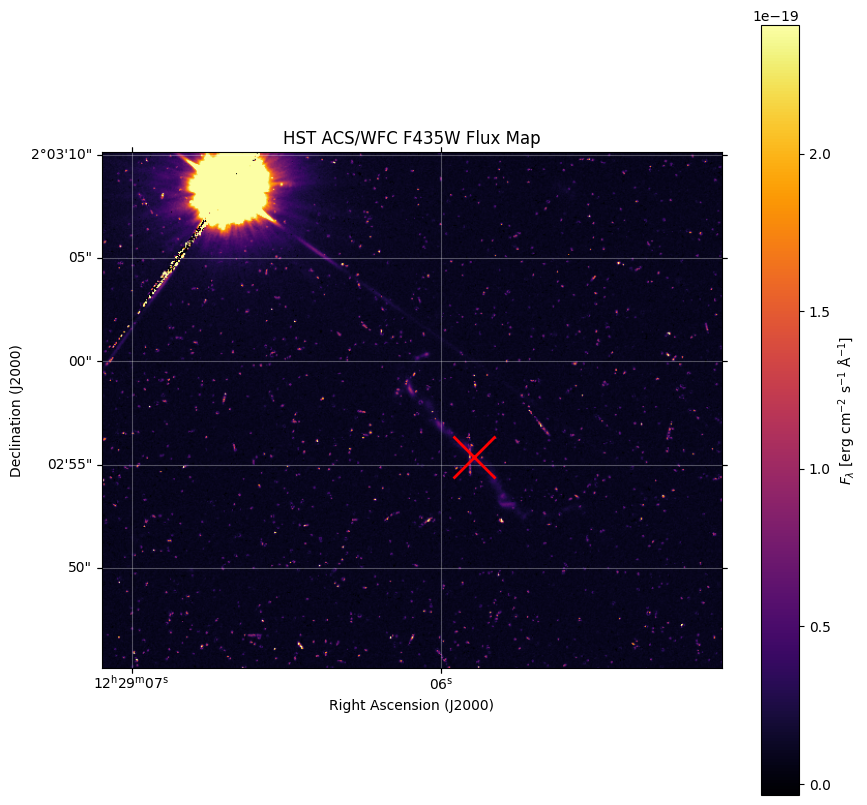

In [28]:
plot_flux_region(
    hdul,
    x_min=1200,
    x_max=1800,
    y_min=1500,
    y_max=2000,
    x_cross = 1560,
    y_cross = 1705
)

### Pinpointing Region of Interest

Below we zoom in to ensure we're pinpointing a significant jet region: 


Selected Region:
x range = [1520, 1600]
y range = [1650, 1750]

Sky Coordinates:
(x_min, y_min) -> RA = 187.275119 deg, DEC = 2.047959 deg
(x_max, y_max) -> RA = 187.274007 deg, DEC = 2.049348 deg

(x_cross, y_cross) -> RA = 187.274535 deg, DEC = 2.048654 deg


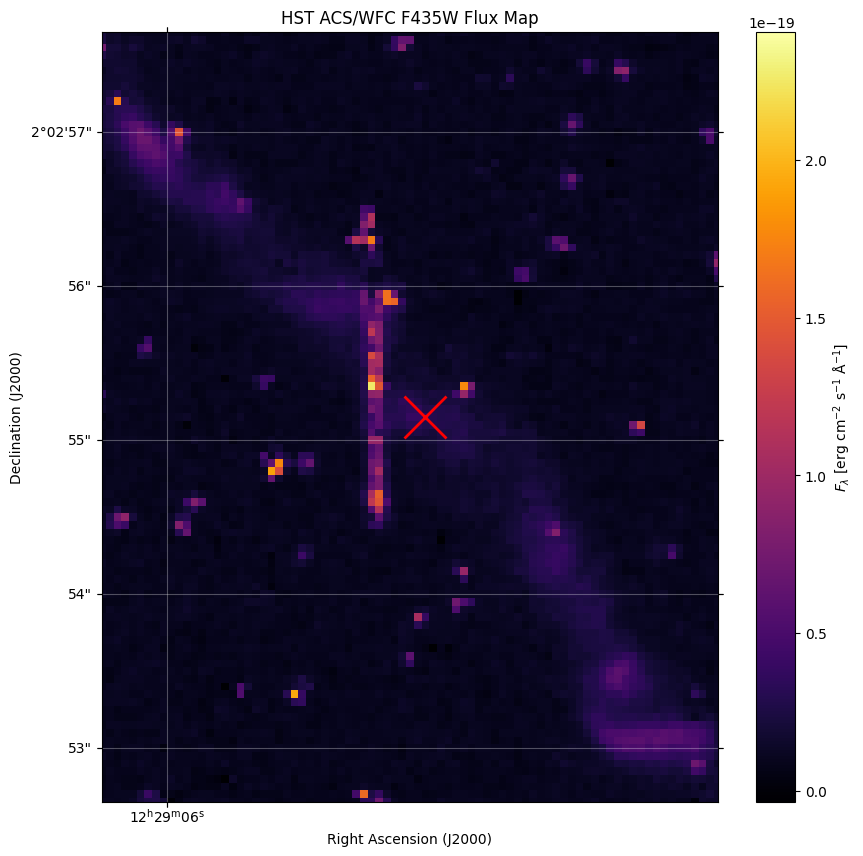

In [134]:
plot_flux_region(
    hdul,
    x_min=1520,
    x_max=1600,
    y_min=1650,
    y_max=1750,
    x_cross = 1562,
    y_cross = 1700
)

## Flux in a Region

In [154]:
import matplotlib.patches as patches
from astropy.wcs import WCS
from astropy.visualization import PercentileInterval

def plot_boxed_region(hdul, corners, ref_point, padding=100, percentile=99.5):
    """
    Plots a zoomed-in flux map with a rectangle defined by 4 endpoints.
    
    Parameters:
    - hdul: The HDUList containing the SCI data and header.
    - corners: List of (x, y) tuples for the 4 corners of the rectangle.
    - ref_point: (x, y) tuple for the center reference point.
    - padding: Pixels to show around the box for context.
    """
    # Load data and header information
    data = hdul[1].data
    header = hdul[1].header
    photflam = header["PHOTFLAM"] #
    
    # Calculate flux density (erg/cm^2/s/A)
    flux_lambda = data * photflam
    wcs = WCS(header)

    '''WE USE THE SAME LIMITS AS BEFORE BECAUSE it's MORE CLEAR: 
    # Determine the view limits based on corners and padding
    x_coords = [c[0] for c in corners]
    y_coords = [c[1] for c in corners]
    x_min, x_max = min(x_coords) - padding, max(x_coords) + padding
    y_min, y_max = min(y_coords) - padding, max(y_coords) + padding
    '''
    x_min = 1530
    x_max = 1580
    y_min = 1670
    y_max = 1730
    #corners = [[1557,1698], [1561,1704], [1565,1702], [1561,1696]]

    # Set up the plot with WCS projection
    fig = plt.figure(figsize=(10, 8))
    ax = plt.subplot(projection=wcs)
    
    # Scale image for visibility
    interval = PercentileInterval(percentile)
    vmin, vmax = interval.get_limits(flux_lambda[np.isfinite(flux_lambda)])
    
    im = ax.imshow(flux_lambda, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
    
    # Draw the rectangle sides using the 4 endpoints
    # A Polygon patch connects the corners and closes the loop
    rect = patches.Polygon(corners, closed=True, linewidth=2, edgecolor='cyan', facecolor='none')
    ax.add_patch(rect)
    
    # Zoom into the region
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.set_xlabel("Right Ascension (J2000)")
    ax.set_ylabel("Declination (J2000)")
    plt.title(f"Boxed Region around ({ref_point[0]}, {ref_point[1]})")
    plt.colorbar(im, label=r"Flux Density $[erg\ cm^{-2}\ s^{-1}\ \AA^{-1}]$")
    plt.show()

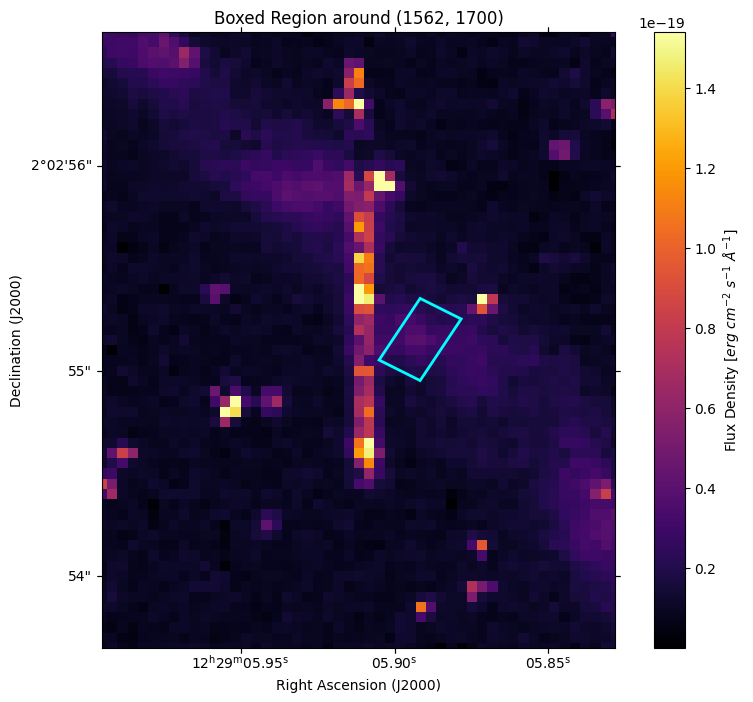

In [155]:
corners = [[1557,1698], [1561,1704], [1565,1702], [1561,1696]]
ref_point = [1562,1700]
plot_boxed_region(hdul, corners, ref_point, padding=100, percentile=99.5)

In [156]:
def get_region_flux(hdul, corners):
    """
    Calculates the total integrated flux density within the rectangular region.
    """
    data = hdul[1].data
    header = hdul[1].header
    photflam = header["PHOTFLAM"] #
    
    # Identify the bounding box from corners
    x_coords = [int(c[0]) for c in corners]
    y_coords = [int(c[1]) for c in corners]
    x_start, x_end = min(x_coords), max(x_coords)
    y_start, y_end = min(y_coords), max(y_coords)
    
    # Slice the science data (SCI)
    region_data = data[y_start:y_end, x_start:x_end]
    
    # Calculate sum and convert to physical units
    # Units: erg/cm^2/s/A
    total_flux_density = np.nansum(region_data) * photflam
    
    print(f"Total flux in region: {total_flux_density:.2e} erg/cm^2/s/A")
    return total_flux_density

In [157]:
get_region_flux(hdul, corners)

Total flux in region: 1.62e-18 erg/cm^2/s/A


np.float32(1.616312e-18)

# Errors

Before we can generalize this framework to the other filters and plot our first SED, we first need to understand the errors in flux and aperture. 

**Fact**: Out weight map data is the inverse variance (1/$\sigma^2$). Hence, at a single point, $$\sigma_{counts, i} = \frac{1}{\sqrt{WHT_i}}$$ This will not be the case for a rectangular box or some other distribution of multiple points. That is because the "drizzle process" makes the error NOT random, and so there is some correlation between neighboring points. See the 'drizzlepac-handbook.pdf' for more info (can also be found at: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.stsci.edu/files/live/sites/www/files/home/scientific-community/software/drizzlepac/_documents/drizzlepac-handbook.pdf&ved=2ahUKEwiFhNTMlbiUAxXJLkQIHcDTLcMQFnoECBcQAQ&usg=AOvVaw3mZJP7sRAhdiNKRcOxES06). 

---

Because we are interested in measuring the decay of particles as they traverse the length of the jet, it is better to take many analyses of distinct individual points rather than a big analysis of multiple points at the same time. Also, there's the added bonus of not having to deal with all this drizzle analysis (at least for this preliminary study). 

**Final Formula**: To get the error in flux we multiply the error in counts ($\sigma_{counts, i}$) by the conversion factor: $$\text{Total Flux Error} = \sigma_{counts, i} \times PHOTFLAM$$

---
For now, we assume **NO error in aperture** in the measurement of the pixel. I have not been able to find formula, but regardless, we are only interested in the error in flux, as well as the wavelength to which we'll plot the flux. Since none of those involve aperture, we should be safe by now. Yet, this might be a significant flaw in the code, so it's worth mentioning for future debugging. 

In [162]:
'''
Given the point:
(x_cross = 1562, y_cross = 1700) ---> RA = 187.274535 deg, DEC = 2.048654 deg
We need to compute the Flux at that point and the error. 
'''

import numpy as np
from astropy.wcs import WCS

def get_flux_and_error_at_coords(hdul, ra, dec): # GEMINI function
    """
    Computes the flux and error at a specific RA and Dec.
    
    Parameters:
    hdul (fits.HDUList): The open FITS file object.
    ra (float): Right Ascension in degrees.
    dec (float): Declination in degrees.
    
    Returns:
    tuple: (flux, error) in units of erg/cm2/s/Angstrom.
    """
    # 1. Access the Science (SCI) and Weight (WHT) extensions
    sci_data = hdul['SCI'].data # hdul[1] == hdul['SCI']
    wht_data = hdul['WHT'].data
    header = hdul['SCI'].header # same WCS info as hdul['WHT'].header ++++ PHOTFLAM!!!!
    
    # 2. Get photometric keyword for flux conversion
    # PHOTFLAM is the inverse sensitivity (erg/cm2/s/A per e-/s)
    photflam = header['PHOTFLAM']
    
    # 3. Initialize WCS and convert RA/Dec to pixel coordinates
    wcs = WCS(header)
    # world_to_pixel returns (x, y) coordinates
    px, py = wcs.world_to_pixel_values(ra, dec)
    
    # Round to nearest integer to find the specific pixel index
    ix, iy = int(np.round(px)), int(np.round(py))
    
    # 4. Extract data at the pixel location
    # Note: numpy uses (y, x) indexing for 2D arrays
    counts_per_sec = sci_data[iy, ix]
    weight = wht_data[iy, ix]
    
    # 5. Calculate Flux and Error
    # Flux = Counts/sec * PHOTFLAM
    flux = counts_per_sec * photflam
    
    # Single pixel error = 1 / sqrt(WHT) converted to flux units
    # Since WHT = 1/sigma^2
    error_counts = 1.0 / np.sqrt(weight)
    error_flux = error_counts * photflam
    
    return flux, error_flux # units: erg cm–2 sec–1 Å–1

In [179]:
# Example Usage:
ra_val = 187.274535
dec_val = 2.048654
flux, error = get_flux_and_error_at_coords(hdul, ra_val, dec_val)
print(f"Flux: {flux:.4e}, Error: {error:.4e} in erg/cm^2/s/Å") 

Flux: 3.4518e-20, Error: 7.3864e-21 in erg/cm^2/s/Å


GEMINI: The fact that the units are "per Angstrom" means this is a spectral flux density—it tells you how much energy is arriving at your detector within a 1-Angstrom wide slice of the spectrum.